# Prediction Test

학습된 CatBoost 모델 1개와 준비된 데이터셋 1개를 사용하되, **`hyundai / 팰리세이드 / 프레스티지` 조합**을 고정으로 선택한 뒤, 해당 조합의 준비된 데이터 1건으로 `vehicle_age_years` 를 +1년씩 증가시키고, 기준 케이스의 `mileage_km / vehicle_age_years` 로 계산한 연간 주행거리를 매년 누적 추가했을 때 예측 가격이 어떻게 변하는지 확인한다.


In [1]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve()
if project_root.name == "src":
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

repo_root = project_root.parent
project_root


PosixPath('/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/predict_engine_research')

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostRegressor


In [3]:
prepared_data_path = project_root / "data" / "prepared_training.csv"
raw_selection_path = repo_root / "data_collection" / "clean" / "output" / "detail_pages_training_ready.csv"
model_path = project_root / "output" / "model.cbm"
feature_manifest_path = project_root / "output" / "feature_manifest.json"

target_brand = "hyundai"
target_model_name = "팰리세이드"
target_trim_name = "프레스티지"
age_deltas = [0, 1, 2, 3, 4, 5]

{
    "prepared_data_path": str(prepared_data_path),
    "raw_selection_path": str(raw_selection_path),
    "model_path": str(model_path),
    "feature_manifest_path": str(feature_manifest_path),
    "target_brand": target_brand,
    "target_model_name": target_model_name,
    "target_trim_name": target_trim_name,
    "age_deltas": age_deltas,
}


{'prepared_data_path': '/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/predict_engine_research/data/prepared_training.csv',
 'raw_selection_path': '/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/data_collection/clean/output/detail_pages_training_ready.csv',
 'model_path': '/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/predict_engine_research/output/model.cbm',
 'feature_manifest_path': '/Users/iwonbin/workspace/Study/boot/SKN28-1st-4team/predict_engine_research/output/feature_manifest.json',
 'target_brand': 'hyundai',
 'target_model_name': '팰리세이드',
 'target_trim_name': '프레스티지',
 'age_deltas': [0, 1, 2, 3, 4, 5]}

In [4]:
feature_manifest = json.loads(feature_manifest_path.read_text(encoding="utf-8"))
feature_columns = feature_manifest["feature_columns"]
categorical_columns = feature_manifest["categorical_columns"]

prepared_frame = pd.read_csv(prepared_data_path)
prepared_frame[categorical_columns] = prepared_frame[categorical_columns].fillna("__missing__").astype(str)

raw_frame = pd.read_csv(raw_selection_path)

combo_rows = prepared_frame.loc[
    (prepared_frame["brand"] == target_brand)
    & (prepared_frame["model_name"] == target_model_name)
    & (prepared_frame["trim_name"] == target_trim_name)
].copy()
raw_combo_rows = raw_frame.loc[
    (raw_frame["brand"] == target_brand)
    & (raw_frame["model_name"] == target_model_name)
    & (raw_frame["trim_name"] == target_trim_name)
].copy()

if combo_rows.empty:
    raise ValueError(
        f"Prepared rows not found for {target_brand=} / {target_model_name=} / {target_trim_name=}"
    )

if raw_combo_rows.empty:
    raise ValueError(
        f"Raw rows not found for {target_brand=} / {target_model_name=} / {target_trim_name=}"
    )

median_price = combo_rows["price_manwon"].median()
base_case = combo_rows.loc[(combo_rows["price_manwon"] - median_price).abs().idxmin()].copy()
base_age_years = float(base_case["vehicle_age_years"])
base_mileage_km = float(base_case["mileage_km"])
annual_mileage_km = base_mileage_km / base_age_years if base_age_years > 0 else 0.0

{
    "prepared_combo_count": int(len(combo_rows)),
    "raw_combo_count": int(len(raw_combo_rows)),
    "median_price_manwon": float(median_price),
    "annual_mileage_km": float(annual_mileage_km),
}


{'prepared_combo_count': 23,
 'raw_combo_count': 23,
 'median_price_manwon': 3050.0,
 'annual_mileage_km': 13018.450184501846}

In [5]:
base_case_display = base_case[["brand", "model_name", "trim_name", "major_category", "size_score", "model_year", "vehicle_age_years", "color", "mileage_km", "price_manwon"]].to_frame().T
base_case_display.insert(0, "target_brand", target_brand)
base_case_display.insert(1, "target_model_name", target_model_name)
base_case_display.insert(2, "target_trim_name", target_trim_name)
base_case_display.insert(3, "raw_combo_count", int(len(raw_combo_rows)))
base_case_display.insert(4, "annual_mileage_km", float(annual_mileage_km))
base_case_display


,target_brand,target_model_name,target_trim_name,raw_combo_count,annual_mileage_km,brand,model_name,trim_name,major_category,size_score,model_year,vehicle_age_years,color,mileage_km,price_manwon
549,hyundai,팰리세이드,프레스티지,23,13018.450185,hyundai,팰리세이드,프레스티지,suv,90.11544,2021,5.42,흰색,70560.0,3050


In [6]:
scenario_rows = []
for delta in age_deltas:
    row = base_case[feature_columns].copy()
    row["vehicle_age_years"] = base_age_years + float(delta)
    row["mileage_km"] = base_mileage_km + (annual_mileage_km * float(delta))
    row["age_delta_years"] = delta
    row["projected_mileage_increase_km"] = annual_mileage_km * float(delta)
    scenario_rows.append(row)

scenario_df = pd.DataFrame(scenario_rows)
scenario_df[categorical_columns] = scenario_df[categorical_columns].astype(str)
scenario_df[["brand", "model_name", "trim_name", "model_year", "vehicle_age_years", "mileage_km", "age_delta_years", "projected_mileage_increase_km"]]


,brand,model_name,trim_name,model_year,vehicle_age_years,mileage_km,age_delta_years,projected_mileage_increase_km
549,hyundai,팰리세이드,프레스티지,2021,5.42,70560.000000,0,0.000000
549,hyundai,팰리세이드,프레스티지,2021,6.42,83578.450185,1,13018.450185
549,hyundai,팰리세이드,프레스티지,2021,7.42,96596.900369,2,26036.900369
549,hyundai,팰리세이드,프레스티지,2021,8.42,109615.350554,3,39055.350554
549,hyundai,팰리세이드,프레스티지,2021,9.42,122633.800738,4,52073.800738
549,hyundai,팰리세이드,프레스티지,2021,10.42,135652.250923,5,65092.250923


In [7]:
model = CatBoostRegressor()
model.load_model(model_path)

predictions = model.predict(scenario_df[feature_columns])
result_df = scenario_df.copy()
result_df["predicted_price_manwon"] = predictions
result_df["base_case_price_manwon"] = float(base_case["price_manwon"])
result_df["predicted_delta_from_base"] = result_df["predicted_price_manwon"] - result_df.loc[result_df["age_delta_years"] == 0, "predicted_price_manwon"].iloc[0]

result_df[["brand", "model_name", "trim_name", "model_year", "vehicle_age_years", "mileage_km", "age_delta_years", "projected_mileage_increase_km", "predicted_price_manwon", "predicted_delta_from_base", "base_case_price_manwon"]]


,brand,model_name,trim_name,model_year,vehicle_age_years,mileage_km,age_delta_years,projected_mileage_increase_km,predicted_price_manwon,predicted_delta_from_base,base_case_price_manwon
549,hyundai,팰리세이드,프레스티지,2021,5.42,70560.000000,0,0.000000,3137.515520,0.000000,3050.0
549,hyundai,팰리세이드,프레스티지,2021,6.42,83578.450185,1,13018.450185,2909.137823,-228.377698,3050.0
549,hyundai,팰리세이드,프레스티지,2021,7.42,96596.900369,2,26036.900369,2522.201499,-615.314021,3050.0
549,hyundai,팰리세이드,프레스티지,2021,8.42,109615.350554,3,39055.350554,2410.941103,-726.574417,3050.0
549,hyundai,팰리세이드,프레스티지,2021,9.42,122633.800738,4,52073.800738,2305.988526,-831.526994,3050.0
549,hyundai,팰리세이드,프레스티지,2021,10.42,135652.250923,5,65092.250923,2135.849348,-1001.666173,3050.0


/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_62630/1989726505.py:18: UserWarning: Glyph 54064 (\N{HANGUL SYLLABLE PAEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_62630/1989726505.py:18: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_62630/1989726505.py:18: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_62630/1989726505.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel_62630/1989726505.py:18: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/pswkqs5s3154t6f3snmgwtjh0000gn/T/ipykernel

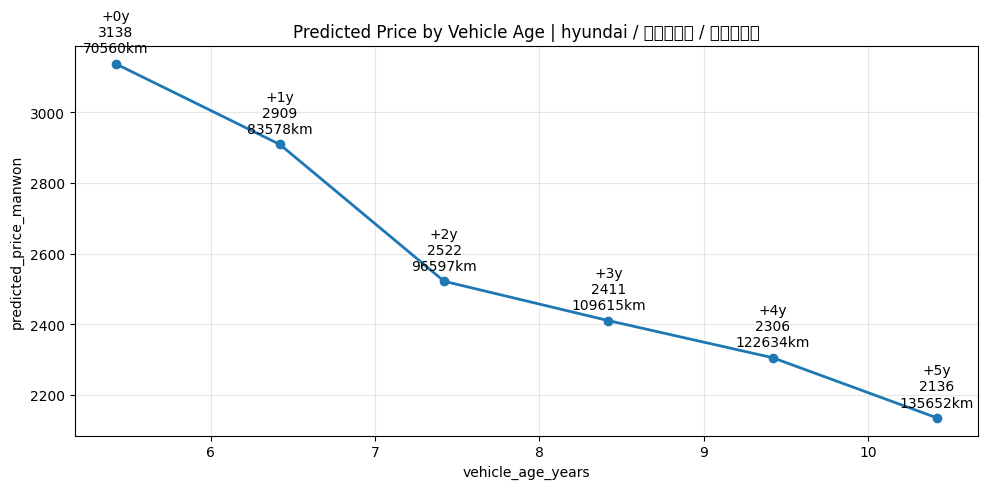

In [8]:
plot_df = result_df[["vehicle_age_years", "mileage_km", "predicted_price_manwon", "age_delta_years"]].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_df["vehicle_age_years"], plot_df["predicted_price_manwon"], marker="o", linewidth=2)
for _, row in plot_df.iterrows():
    ax.annotate(
        f"+{int(row['age_delta_years'])}y\n{row['predicted_price_manwon']:.0f}\n{row['mileage_km']:.0f}km",
        (row["vehicle_age_years"], row["predicted_price_manwon"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

ax.set_title(f"Predicted Price by Vehicle Age | {base_case['brand']} / {base_case['model_name']} / {base_case['trim_name']}")
ax.set_xlabel("vehicle_age_years")
ax.set_ylabel("predicted_price_manwon")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Single Fixed Scenario

`hyundai / 팰리세이드 / 프레스티지` 조합에 대해 `vehicle_age_years = 5`, `mileage_km = 96000` 을 직접 넣어 단건 예측을 확인한다.


In [10]:
fixed_case = base_case[feature_columns].copy()
fixed_case["vehicle_age_years"] = 6.0
fixed_case["mileage_km"] = 96000.0

fixed_case_df = pd.DataFrame([fixed_case])
fixed_case_df[categorical_columns] = fixed_case_df[categorical_columns].astype(str)

fixed_prediction = float(model.predict(fixed_case_df[feature_columns])[0])

fixed_result_df = fixed_case_df.copy()
fixed_result_df["predicted_price_manwon"] = fixed_prediction
fixed_result_df[["brand", "model_name", "trim_name", "model_year", "vehicle_age_years", "mileage_km", "predicted_price_manwon"]]


,brand,model_name,trim_name,model_year,vehicle_age_years,mileage_km,predicted_price_manwon
549,hyundai,팰리세이드,프레스티지,2021,6.0,96000.0,2822.309268


주의: 이 테스트는 `hyundai / 팰리세이드 / 프레스티지` 고정 조합에서 기준 1건을 잡고, `vehicle_age_years` 를 늘릴 때 기준 케이스의 연간 평균 주행거리(`mileage_km / vehicle_age_years`)만큼 `mileage_km` 도 함께 증가시키는 민감도 확인용이다. `model_year` 는 고정이며, 실제 시장 가격은 옵션, 사고 여부, 판매시점 등 다른 변수의 영향도 함께 받는다.

200 만원 차이 
주의 : 해당 매물은 학습 데이터에 없던 매물입니다. 
예시 : https://m.kbchachacha.com/public/web/search/list.kbc?makerCode=101&classCode=2722&carCode=2971#makerCode=101&classCode=2722&carCode=2971
